# Exercise 5

In [ ]:
import pandas as pd
import numpy as np

from scipy import stats
from scipy.stats import chi2_contingency


## Part 1: ANOVA

A teacher wants to investigate whether different teaching methods affect students’ exam scores. The dataset contains 50 students, each assigned to one of three teaching methods (A, B, or C).

Question: "Is there a difference in mean exam scores among students taught using three different teaching methods?"

- Independent variable (factor): Teaching Method (A, B, C)
- Dependent variable: Exam Score (numeric)

In [ ]:
url = "https://github.com/robitussin/CCDATSCL_EXERCISES/blob/f56f00991116fcb717a8827d324aa6f599dea366/exam_scores.csv?raw=true"

df_exam_scores = pd.read_csv(url)
df_exam_scores


,StudentID,Method,Score
0,1,A,79
1,2,A,77
2,3,A,82
3,4,A,75
4,5,A,80
5,6,A,78
6,7,A,83
7,8,A,76
8,9,A,81
9,10,A,74


Calculate the number of students in each teaching method.

In [ ]:
df_exam_scores['Method'].value_counts()


,count
Method,
A,17
B,17
C,16


Compute the mean and standard deviation of exam scores for each group.

In [ ]:
df_exam_scores.groupby('Method')['Score'].agg(['mean', 'std'])


,mean,std
Method,,
A,78.588235,2.575336
B,86.294118,2.365500
C,71.937500,1.768945


Use a plot to show the exam scores by teaching method.

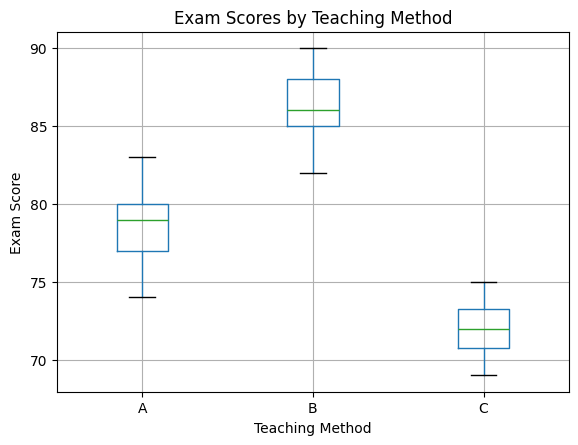

In [ ]:
import matplotlib.pyplot as plt

df_exam_scores.boxplot(column='Score', by='Method')
plt.title("Exam Scores by Teaching Method")
plt.suptitle("")
plt.xlabel("Teaching Method")
plt.ylabel("Exam Score")
plt.show()


Perform the ANOVA Test
- Use scipy.stats.f_oneway to conduct a one-way ANOVA.
- Report the F-statistic and p-value.
- Using a significance level of α = 0.05, state whether you reject or fail to reject H₀.

In [ ]:
scores_A = df_exam_scores[df_exam_scores['Method'] == 'A']['Score']
scores_B = df_exam_scores[df_exam_scores['Method'] == 'B']['Score']
scores_C = df_exam_scores[df_exam_scores['Method'] == 'C']['Score']

f_stat, p_value = stats.f_oneway(scores_A, scores_B, scores_C)

f_stat, p_value


(np.float64(165.17845596593054), np.float64(5.5032645988699085e-22))

Interpret the results. What does it say about the relationship between teaching method and exam scores?

In [ ]:
print(
    "The three instructional strategies produce statistically significant differences in mean exam scores. "
    "This suggests that teaching methods have a significant impact on student exam performance."
)


The three instructional strategies produce statistically significant differences in mean exam scores. This suggests that teaching methods have a significant impact on student exam performance.


## Part 2: Chi-squared

A survey was conducted to see if there is a relationship between gender and littering behavior.

Question:
"Is gender associated with littering behavior?"

Each row represents one person.

In [ ]:
url = "https://github.com/robitussin/CCDATSCL_EXERCISES/blob/f56f00991116fcb717a8827d324aa6f599dea366/litteringdata.csv?raw=true"

df_littering_data = pd.read_csv(url)
df_littering_data

,ID,Gender,Litter
0,1,Male,Yes
1,2,Male,Yes
2,3,Male,Yes
3,4,Male,Yes
4,5,Male,Yes
5,6,Male,Yes
6,7,Male,Yes
7,8,Male,Yes
8,9,Male,Yes
9,10,Male,Yes


Count the number of observations in each category for Gender and Litter separately.


In [ ]:
# Count for Gender
df_littering_data['Gender'].value_counts()

# Count for Litter
df_littering_data['Litter'].value_counts()


,count
Litter,
No,22
Yes,18


Using `pd.crosstab()`, create a contingency table showing counts of littering behavior for each gender.
- Write down the row totals, column totals, and grand total from the table.

In [ ]:
contingency_table = pd.crosstab(df_littering_data['Gender'], df_littering_data['Litter'])
contingency_table


Litter,No,Yes
Gender,,
Female,14,6
Male,8,12


State the null hypothesis (H₀) and alternative hypothesis (H₁) for this chi-squared test.

In [11]:
import pandas as pd
from scipy.stats import chi2_contingency


# Create contingency table
contingency_table = pd.crosstab(
    df_littering_data['Gender'],
    df_littering_data['Litter']
)

# Perform chi-squared test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

# Display results
print("Chi-squared statistic:", chi2)
print("p-value:", p_value)
print("Degrees of freedom:", dof)

Chi-squared statistic: 2.525252525252525
p-value: 0.11203684368556356
Degrees of freedom: 1


Use scipy.stats.chi2_contingency to calculate:
- Chi-squared statistic
- p-value
- Degrees of freedom

Using a significance level of `α = 0.05`, determine whether to reject or fail to reject H₀.


In [12]:
alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis (H₀).")
else:
    print("Fail to reject the null hypothesis (H₀).")


Fail to reject the null hypothesis (H₀).


Interpret your results. Is there evidence that gender and littering behavior are associated?

In [13]:
print(
    "The p-value is compared with the significance level of 0.05 based on the results of the chi-squared test. "
   "A statistically significant correlation between gender and littering behavior is demonstrated if the p-value is less than 0.05."
   "Otherwise, there is not enough data to draw the conclusion that littering behavior and gender are related."
)


The p-value is compared with the significance level of 0.05 based on the results of the chi-squared test. A statistically significant correlation between gender and littering behavior is demonstrated if the p-value is less than 0.05.Otherwise, there is not enough data to draw the conclusion that littering behavior and gender are related.
